Metadata Filtering                  
벡터 유사도 계산 전에(또는 함께) 문서의 메타데이터 조건으로 검색 대상을 제한하는 기법            

In [32]:
%pip install -U langchain langchain-classic langchain-community langchain-core langchain-openai langchain-pinecone lark

   ---------------------------------------- 0.0/571.5 kB ? eta -:--:--
   ---------------------------------------- 571.5/571.5 kB 20.6 MB/s  0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.6.0
    Uninstalling langchain-core-1.6.0:
      Successfully uninstalled langchain-core-1.6.0
Note: you may need to restart the kernel to use updated packages.


In [1]:
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')

In [4]:
import pandas as pd
document_df = pd.read_csv('documents_meta.csv')

queries_df = pd.read_csv('queries_meta_v2.csv')

In [18]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore


embeddings = OpenAIEmbeddings(
    model='text-embedding-3-small'
)


# ir-meta 인덱스와 연결
vector_store = PineconeVectorStore(
    index_name='ir-meta',
    embedding=embeddings
)

print('ir-meta vector_store 연결 완료!')

ir-meta vector_store 연결 완료!


In [19]:
from pinecone import Pinecone, ServerlessSpec
from langchain_pinecone import PineconeVectorStore
pc = Pinecone()
index_names = pc.list_indexes().names()
print(index_names)

# 압축 문서를 저장할 별도 인덱스 생성
if 'ir-compressed' not in index_names:
    pc.create_index(
        name='ir-meta',
        dimension=1536,
        metric='cosine',
        spec=ServerlessSpec(region='us-east-1', cloud='aws')
    )
    print('ir-meta 인덱스 생성 완료!')
else:
    print('ir-meta 인덱스가 이미 존재합니다.')

['ir-meta', 'ir']


PineconeApiException: (409)
Reason: Conflict
HTTP response headers: HTTPHeaderDict({'content-type': 'application/json', 'vary': 'origin, access-control-request-method, access-control-request-headers', 'access-control-allow-origin': '*', 'access-control-expose-headers': '*', 'x-pinecone-api-version': '2025-04', 'x-cloud-trace-context': '43c45205e3738649dff59cffed937503', 'date': 'Wed, 02 Sep 2026 00:37:03 GMT', 'server': 'Google Frontend', 'Content-Length': '85', 'Via': '1.1 google', 'Alt-Svc': 'h3=":443"; ma=2592000,h3-29=":443"; ma=2592000'})
HTTP response body: {"error":{"code":"ALREADY_EXISTS","message":"Resource  already exists"},"status":409}


In [23]:
docs_to_index = []

# Document Upsert
- 임베딩 변환할 텍스트 외의 컬럼은 metadata 속성(dict)안에 저장이 되어 있어야 검색에 활용할 수 있다.

In [24]:
docs_to_index = []

for idx, row in tqdm(
    document_df.iterrows(),
    total=len(document_df)
):
    metadata = {
        'doc_id': str(row['doc_id']),
        'title': str(row['title']),
        'author': str(row['author']),
        'category': str(row['category'])
    }

    doc = Document(
        page_content=str(row['content']),
        metadata=metadata
    )

    docs_to_index.append(doc)

vector_store.add_documents(
    documents=docs_to_index,
    ids=[doc.metadata['doc_id'] for doc in docs_to_index]
)






  0%|          | 0/30 [00:00<?, ?it/s]

['D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'D16',
 'D17',
 'D18',
 'D19',
 'D20',
 'D21',
 'D22',
 'D23',
 'D24',
 'D25',
 'D26',
 'D27',
 'D28',
 'D29',
 'D30']

## 메타데이터 필터를 사용한 벡터 검색

https://python.langchain.com/docs/integrations/vectorstores/

LangChain의 `vectorstore.similarity_search`에서 **filter**를 사용하는 방법은 벡터스토어 종류에 따라 약간 다르지만, 기본적으로 **문서의 메타데이터(metadata)를 조건으로 검색 결과를 제한**하는 데 사용한다.

**고급 필터링 (MongoDB 스타일 연산자)**

몇몇 벡터스토어(예: FAISS, Chroma 등)는 **MongoDB 스타일의 연산자**를 지원한다. 예를 들어, 특정 값과 일치하는 것뿐만 아니라, 크거나, 작거나, 리스트 내 포함 등 다양한 조건을 줄 수 있다.

지원 연산자 예시:
- `$eq`: 같음
- `$neq`: 같지 않음
- `$gt`: 큼
- `$lt`: 작음
- `$gte`: 크거나 같음
- `$lte`: 작거나 같음
- `$in`: 리스트 내 포함
- `$nin`: 리스트 내 미포함
- `$and`, `$or`, `$not`: 논리 연산

In [26]:
query = ''

results = vector_store.similarity_search(
    query,
    k=5,
    filter={
        'category': {
            '$in': ['AI']
        }
    }
)

for doc in results:
    print(f"doc_id: {doc.metadata.get('doc_id')}")
    print(f"title: {doc.metadata.get('title')}")
    print(f"category: {doc.metadata.get('category')}")
    print(f"content: {doc.page_content}")
    print()

## SelfQueryRetriever

**SelfQueryRetriever**는 사용자의 자연어 질문을 분석하여 쿼리 자체에 포함된 **메타데이터 필터**와 **벡터 검색용 쿼리**를 분리하여 실행하는 검색 방식이다.

일반적인 벡터 검색은 질문의 '의미'만으로 데이터를 찾지만, SelfQueryRetriever는 LLM을 활용해 질문에서 조건(필터)을 추출한다.

**1. 작동 원리**

사용자가 "2023년 이후에 개봉한 평점 8.5 이상의 SF 영화 찾아줘"라고 질문하면, SelfQueryRetriever는 내부적으로 다음과 같은 과정을 거친다.

1. **질문 분석**: LLM이 질문을 해석하여 검색어(Query)와 필터 조건(Metadata Filter)을 생성한다.
* **검색어**: "SF 영화"
* **필터**: `release_year > 2023 AND rating >= 8.5`


2. **쿼리 실행**: 생성된 필터를 벡터 데이터베이스(Vector DB)의 메타데이터에 적용함과 동시에 검색어로 유사도 검색을 수행한다.
3. **결과 반환**: 두 조건이 모두 충족된 결과물만 사용자에게 전달한다.

**2. 주요 구성 요소**

| 구성 요소 | 설명 |
| --- | --- |
| **Document Content Description** | 데이터셋이 어떤 내용을 담고 있는지 LLM에게 설명하는 텍스트이다. |
| **Metadata Field Info** | 각 메타데이터 필드의 이름, 타입(정수, 문자열 등), 의미를 정의한 정보이다. |
| **LLM** | 자연어 질문을 구조화된 쿼리(필터)로 변환하는 역할을 한다. |
| **Vector Store** | 실제 데이터와 메타데이터가 저장된 저장소이다. |

**3. 왜 사용하는가?**

* **정확도 향상**: "최근에 나온"이나 "특정 점수 이상" 같은 정량적 조건은 의미론적 유사성만으로는 정확히 필터링하기 어렵다. 이를 논리적 필터로 처리함으로써 검색 결과의 신뢰도를 높인다.
* **자연스러운 인터페이스**: 사용자가 SQL이나 복잡한 필터 문법을 배울 필요 없이, 일상적인 언어로 정교한 검색이 가능하다.
* **효율성**: 불필요한 데이터를 벡터 검색 단계에서 미리 배제하여 검색 범위를 좁힐 수 있다.

In [36]:
from langchain.chat_models import init_chat_model
from langchain_classic.retrievers import SelfQueryRetriever
from langchain_classic.chains.query_constructor.schema import AttributeInfo
from langchain_classic.retrievers.self_query.pinecone import PineconeTranslator
llm = init_chat_model('gpt-5.6-luna', temperature = 0)

# 메타데이터 검색에 활용할 메타데이터
metadata_field_info = [
    AttributeInfo(name = 'doc_id', type = 'string', description = '문서 식별 번호'),
    AttributeInfo(name = 'author', type = 'string', description = '문서를 작성한 저자 이름'),
    AttributeInfo(name = 'category', type = 'list[string]', description = '문서의 분류 목록'),
    AttributeInfo(name = 'text', type = 'string', description = '문서 제목')
]

document_content_description = '다양한 분류의 텍스트 데이터셋'

self_query_retriever = SelfQueryRetriever.from_llm(
    llm = llm,
    vectorstore = vector_store,
    document_contents = document_content_description,
    metadata_field_info = metadata_field_info ,
    structured_query_translator=PineconeTranslator()   # Pinecone 필터 변환
)

# 메타데이터 필터링 수행

In [38]:
from tqdm.auto import tqdm

results_list = []
self_query_results = {}

for idx, row in tqdm(queries_df.iterrows(), total = len(queries_df)): # compressed_df을 행 단위로 순회
    qid = row['query_id']
    query_text = row['query_text']
    docs = self_query_retriever.invoke(query_text)
    structured_query = self_query_retriever.query_constructor.invoke({'query': query_text})
    self_query_results[qid] = [doc.metadata['doc_id'] for doc in docs[:5]]

    # DataFrame 시각화용 결과3
    results_list.append({
        'query_id': qid,
        'query_text': query_text,
        'structured_query': str(structured_query),
        'retrieved_doc_ids': self_query_results[qid]
    })

   
    

  0%|          | 0/30 [00:00<?, ?it/s]

In [39]:
pd.set_option('display.max_colwidth', None)

results_df = pd.DataFrame(results_list)
results_df

,query_id,query_text,structured_query,retrieved_doc_ids
0,Q01,저자 김민수의 문서를 모두 보여줘,query=' ' filter=None limit=None,"[D21, D11, D1]"
1,Q02,저자 이영희의 문서를 모두 보여줘,query=' ' filter=None limit=None,"[D28, D17, D16, D22]"
2,Q03,저자 박지훈의 문서를 모두 보여줘,query=' ' filter=None limit=None,"[D3, D23, D13]"
3,Q04,저자 최수정의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='최수정') limit=None","[D28, D17, D16, D22]"
4,Q05,저자 정우성의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='정우성') limit=None","[D25, D15, D5]"
5,Q06,저자 한예슬의 문서를 모두 보여줘,query=' ' filter=None limit=None,"[D28, D17, D16, D22]"
6,Q07,저자 강다니엘의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='강다니엘') limit=None","[D17, D27, D7]"
7,Q08,저자 오정연의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='오정연') limit=None","[D28, D18, D8]"
8,Q09,저자 신동엽의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='신동엽') limit=None","[D9, D19, D29]"
9,Q10,저자 윤아름의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='윤아름') limit=None","[D28, D17, D16, D22]"


In [43]:
import numpy as np

def parse_relevant(relevant_str) -> dict[str, int]:
    """
    참조문서 답안 문자열을 dict로 파싱하는 함수

    relevant_str = "D1=3;D4=1;D30=1" -> {'D1': 3, 'D4': 1, 'D30': 1}
    """
    pairs = relevant_str.split(';')  # ';' 기준으로 분리
    rel_dict = {}       # {doc_id: grade, ...}
    for pair in pairs:
        doc_id, grade = pair.split('=')  # '=' 기준으로 분리
        rel_dict[doc_id] = int(grade)    # {doc_id: grade, ...} 
    return rel_dict

# 예측 결과와 실제 정답을 비교해서 평가지표를 계산하는 함수
def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # Precision@k
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict])  # top-k 적중 개수
    precision = hits / k  # 정밀도 = 맞춘갯수 / 전체갯수

    # Recall@k
    total_relevant = len(relevant_dict)  # 전체 관련 문서 수
    recall = hits / total_relevant if total_relevant > 0 else 0  # 재현율 = 관련 문서 맞춘 수

    # MRR : 예측치 중 첫 관련문서 순위 점수
    rr = 0  # 관련 문서 수
    # 전체 랭킹에서 첫번째 적중된 것을 찾음
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1)  # 첫 적중 순위 역수
            break  # 첫 번째 적중 rr 반영 후 반복문 탈출
    
    # AP (MAP를 위한 사전 계산)
    num_correct = 0  # 현재까지의 적중 횟수
    precisions = []  # 적중시의 precision
    for idx, doc in enumerate(predicted[:k]):  # top-k 범위에서
        if doc in relevant_dict:
            num_correct += 1    # 적중시 1 누적
            precisions.append(num_correct / (idx + 1))  # 현재 시점의 precision 기록
    ap = np.mean(precisions) if precisions else 0  # pricision 평균치 사용, 없으면 0
    
    return precision, recall, rr, ap

# 여러 쿼리에 대한 평균 성능지표 계산하는 함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], []  # 지표별 결과 저장

    for idx, row in queries_df.iterrows():
        qid = row['query_id']  # 쿼리 ID
        relevant_dict = parse_relevant(row['relevant_doc_ids'])  # 정답 dict 파싱
        predicted = method_results[qid]  # 해당 쿼리의 예측 랭킹
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k)  # 지표 계산
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)
    
    return {
        'P@k': np.mean(prec_list),  # 쿼리 평균 Precision@k
        'R@k': np.mean(rec_list),   # 쿼리 평균 Recall@k
        'MRR': np.mean(rr_list),    # 쿼리 평균 MRR
        'MAP': np.mean(ap_list),    # 쿼리 평균 MAP
    }

In [44]:
dense_results = {}

for idx, row in tqdm(queries_df.iterrows()):
    qid = row['query_id']
    query_text = row['query_text']

    docs = vector_store.similarity_search(query_text, k=5) # 원본 벡터 서치
    dense_results[qid] = [doc.metadata['doc_id'] for doc in docs]




    

0it [00:00, ?it/s]

In [45]:
dense_metrics = evaluate_all(dense_results, queries_df, k = 5)
self_query_mertics = evaluate_all(self_query_results, queries_df, k=5)

In [46]:
metrics_df = pd.DataFrame({
    'Metrics': ['P@5', 'R@5', 'MRR', 'MAP'],  # 지표 이름
    'Original': [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']],
    'Compressed': [self_query_mertics['P@k'], self_query_mertics['R@k'], self_query_mertics['MRR'], self_query_mertics['MAP']],
})

metrics_df


,Metrics,Original,Compressed
0,P@5,0.233333,0.166667
1,R@5,0.458889,0.258056
2,MRR,0.400000,0.361111
3,MAP,0.379259,0.361111


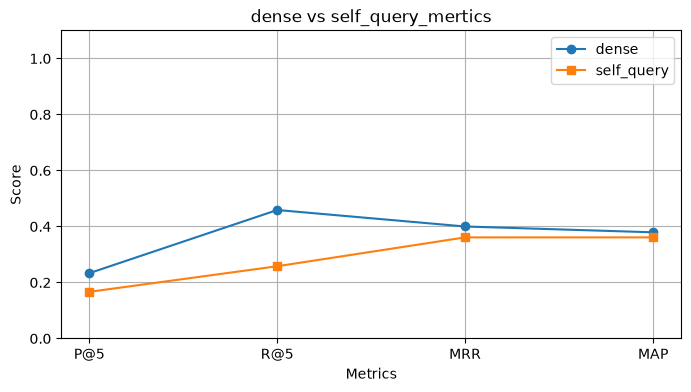

In [47]:
import matplotlib.pyplot as plt

metrics = ['P@5', 'R@5', 'MRR', 'MAP']
dense_vals = [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']]
self_query_vals = [self_query_mertics['P@k'], self_query_mertics['R@k'], self_query_mertics['MRR'], self_query_mertics['MAP']]

x = range(len(metrics))  # 0~3

plt.figure(figsize=(8, 4))
plt.plot(x, dense_vals, marker='o', label='dense')
plt.plot(x, self_query_vals, marker='s', label='self_query')
plt.xticks(x, metrics)  # x축 눈금은 0~3 -> 지표명
plt.ylim(0, 1.1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('dense vs self_query_mertics')
plt.legend()
plt.grid()
plt.show()

## 왜 이런 결과가 나왔나?

- **Dense Retrieval**
  - 문서의 **의미적 유사도**만을 기준으로 판단
  - 작성자(author), 카테고리(category)와 같은 **구조적 조건을 직접 반영하지 못함**

- **Self-Query Retriever (Metadata 기반)**
  - 자연어 질의에서 **조건을 자동으로 추출**
  - 추출된 조건을 **메타데이터 필터로 강제 적용**하여 검색

예를 들어,

> **“이영희가 쓴 여행 관련 글”**

과 같은 질의는  
- Dense Retrieval에게는 의미적으로 **모호한 질문**이지만  
- Metadata 검색에게는 **명확한 조건 기반 질의**가 된다.

---

## 실무 결론 (중요)

### 권장 검색 파이프라인
Self-Query / Metadata Filtering  
↓
Dense Retrieval  
↓
ReRank (선택)

- **조건이 명확한 질의** → Metadata 검색 우선
- **의미적 탐색 중심 질의** → Dense Retrieval 활용
- **실제 서비스 환경** → 두 방식을 결합한 Hybrid 전략 적용

---

## 한 줄 결론 (교안 / 발표용)

> **구조적 조건이 포함된 질의에서는 Dense Retrieval보다 Metadata 기반 검색이 압도적으로 높은 정확도를 보인다.**